# ACCESS-OM3 MC 25km JRA RYF Scaling

End -to-end pipeline generating scaling plots for the [ACCESS-OM3 MC 25km JRA RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_25km_jra_ryf).


In [1]:
%load_ext autoreload
%autoreload 2

# Record package versions for future reference
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling", "payu", "experiment_generator", "experiment_runner"):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.5.dev3+g45c8354dc
access.profiling: 0.2.dev39+gab3f21653
payu: 1.3.6+3.g6b40651
experiment_generator: 0.10.2
experiment_runner: 0.3.3.dev1+gdbb5c158f


## Setup

The following variables control where the configurations and model run outputs are saved.

In [2]:
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

work_path = f"/scratch/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive"

# Define the configuration
GLOBAL_GRID = Domain(shape=(1440, 1152))
OM3_MC_25KM = OM3Configuration(
    name="MC-25km",
    ocean=GLOBAL_GRID,
    sea_ice=GLOBAL_GRID,
    atmosphere=GLOBAL_GRID,
    runoff=GLOBAL_GRID,
)

om3_profiling = OM3Profiling(work_dir=Path(work_path), archive_dir=Path(archive_path), configuration=OM3_MC_25KM)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="29ccf118e5bdc09a246d339ac64f330c5b2e9473")

## Generate Experiments

We will perform a simple scaling study, varying the total number of Sapphire nodes used over `[1, 2, 4, 8, 12. 16, 20, 26, 32]`. For each node count, we will generate different parallel layouts by changing how cores are allocated to the different components.   

In [4]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint

num_nodes_list = [1.0, 2.0, 4.0, 8.0, 12.0, 16.0, 20.0, 26.0, 32.0]
cores_per_node = 104

# Define how the cores should be allocated to the components:
#   - MOM6 uses between 85% and 95% of the cores available and has at least 9 times more cores than the other components.
#   - Only generate layouts where the number of cores assigned to MOM6 is a multiple of 'step'
#     (this is to reduce the total number of generated layouts without reducing the quality of the sampling too much).  
#   - Reject layouts that waste more than 'wasted_frac' cores.
#   - Require CICE domains to have a certain aspect ratio ('cice_ratio') to reduce internal load-inbalance.
# Note that 'wasted_frac', 'cice_ratio' and 'step' depend on the number of nodes.
def allocation_strategy(num_nodes):
    if num_nodes >= 12.0:
        waste_frac = 0.01
        cice_ratio = 1.5
        step = 15
    elif num_nodes >= 4.0:
        waste_frac = 0.01
        cice_ratio = 2.0
        step = 5
    else:
        waste_frac = 0.01
        cice_ratio = 2.5
        step = 2
    return RootAllocation(
        subcomponents={
            "ocn": FreeAllocation(min_core_fraction=0.85, core_step=step),
            "shared": FreeAllocation(min_core_fraction=0.05, core_step=step,
                 subcomponents={
                    "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=cice_ratio),),),
                    "cpl": WholeRangeAllocation(),
                    "rof": WholeRangeAllocation(),
                    "atm": WholeRangeAllocation(),
                },
            ),
        },
        local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=waste_frac),),
        group_constraints=(
           RankRatioGroupConstraint(name_a="ocn", name_b="shared", min_ratio=9.0),
           RankRatioGroupConstraint(name_a="shared", name_b="ocn", min_ratio=0.1),
       ),
    )

# Write how many layouts are going to be generated for each number of nodes
from access.config.parallel_layouts import iter_layouts
for num_nodes in num_nodes_list:
    layouts = list(iter_layouts(OM3_MC_25KM.parallel_component, int(num_nodes*cores_per_node), allocations=allocation_strategy(num_nodes)))
    print(f"Num nodes: {num_nodes}, Num layouts: {len(layouts)}")

Num nodes: 1.0, Num layouts: 1
Num nodes: 2.0, Num layouts: 4
Num nodes: 4.0, Num layouts: 3
Num nodes: 8.0, Num layouts: 4
Num nodes: 12.0, Num layouts: 3
Num nodes: 16.0, Num layouts: 2
Num nodes: 20.0, Num layouts: 2
Num nodes: 26.0, Num layouts: 6
Num nodes: 32.0, Num layouts: 5


In [4]:
# Generate the configuration and write to file
from ruamel.yaml.scalarstring import DoubleQuotedScalarString as dq
run_length = 2 #
run_units = "nmonths" # what nuopc.runconfig can understand as the value for both restart_option and stop_option
control_options = {
            "config.yaml": {
                "modules": {
                    "use": ["/g/data/vk83/modules"],
                    "load": ["access-om3/2026.05.004"],
                },
                "mem": "REMOVE",
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
                "collate": "REMOVE",
                "archive": "REMOVE",
                "env":
                    {"ESMF_RUNTIME_PROFILE" : dq("on"), "ESMF_RUNTIME_PROFILE_OUTPUT" : dq("SUMMARY")},
            },
            "MOM_input": {
                "AUTO_MASKTABLE": "True",
                "MASKTABLE": "REMOVE",
                "LAYOUT": "REMOVE",
                "IO_LAYOUT": "REMOVE",
            },
            "nuopc.runconfig": {
                "CLOCK_attributes": {
                    "stop_n": run_length,
                    "stop_option": run_units,
                    "restart_n": run_length,
                    "restart_option": run_units,
                },
            },
        }

def walltime_fn(num_nodes):
    return min(2.0 * 27.0/num_nodes, 24) # use a 2 hrs time for 27-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=cores_per_node, walltime=walltime_fn, allocations=allocation_strategy)

No new experiments to generate. Will skip generation.


## Run experiments

Next we run the experiments

In [3]:
om3_profiling.run_experiments()

## Parsing and plotting experiment results

In [3]:
# Parse the data
om3_profiling.parse_profiling_data()

In [4]:
# Get the best (fastest) layouts for each node count  (ignoring layouts that failed)
from access.profiling.metrics import tmax
best_experiments = om3_profiling.select_best_experiments(component="ESMF",region="[ensemble] RunPhase1", metric=tmax)
best_experiments

['om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10',
 'om3-layout_MC-25km_atm_20_cpl_20_ice_5x4_ocn_188_rof_20',
 'om3-layout_MC-25km_atm_40_cpl_40_ice_10x4_ocn_375_rof_40',
 'om3-layout_MC-25km_atm_80_cpl_80_ice_10x8_ocn_745_rof_80',
 'om3-layout_MC-25km_atm_120_cpl_120_ice_12x10_ocn_1125_rof_120',
 'om3-layout_MC-25km_atm_165_cpl_165_ice_15x11_ocn_1485_rof_165',
 'om3-layout_MC-25km_atm_195_cpl_195_ice_15x13_ocn_1875_rof_195',
 'om3-layout_MC-25km_atm_270_cpl_270_ice_15x18_ocn_2430_rof_270',
 'om3-layout_MC-25km_atm_330_cpl_330_ice_22x15_ocn_2985_rof_330']

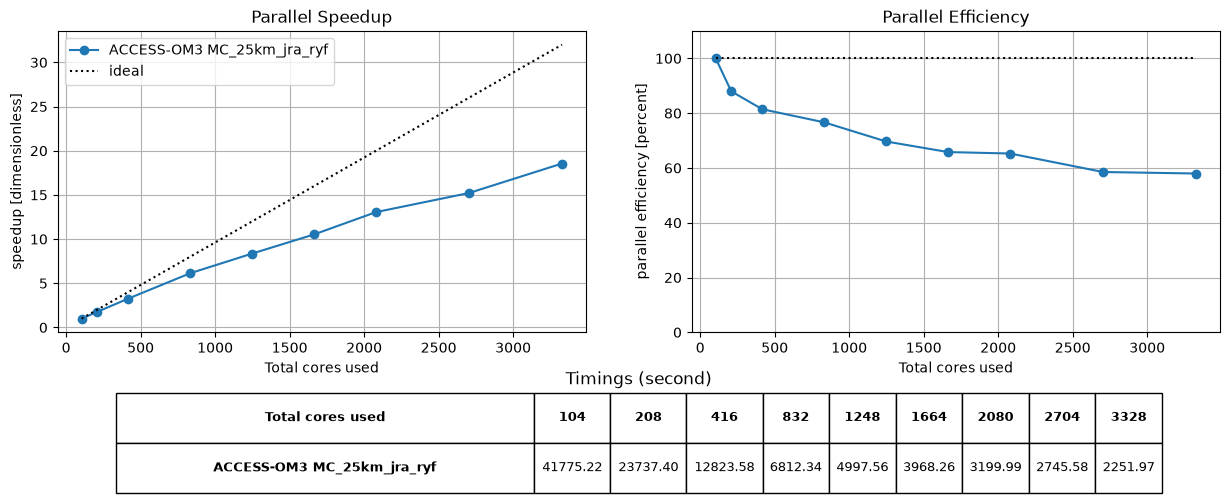

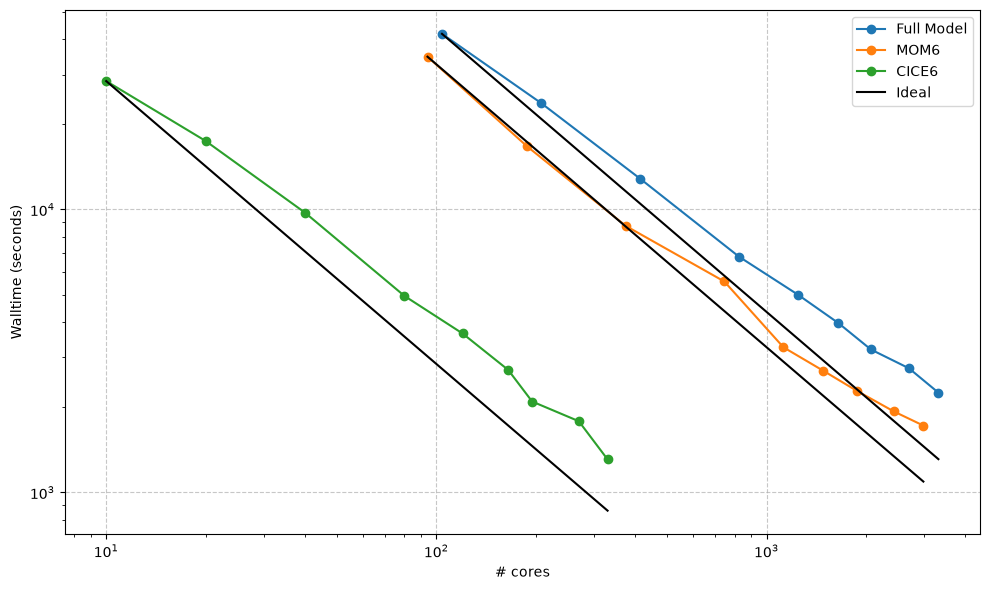

In [5]:
# Plot the parallel speedup and efficiency of the time-stepping regions for this configuration
fig = om3_profiling.plot_scaling_data(
    components=["ESMF"],
    regions=[
        ["[ensemble] RunPhase1"],
    ],
    metric=tmax,
    region_relabel_map={
        "[ensemble] RunPhase1": "ACCESS-OM3 MC_25km_jra_ryf",
    },
    experiments=best_experiments,
    xlabel="Total cores used",
)

# Plot the per-component walltime of the the time-stepping regions as a function of the number of cores 
from access.profiling.manager import RegionGroup
fig2 = om3_profiling.plot_component_scaling_data(
    [
        RegionGroup("ESMF", ["[ensemble] RunPhase1"], component="ACCESS-OM3 MC-25km"),
        RegionGroup("ESMF", ["[OCN] RunPhase1"], component="ocn"),
        RegionGroup("ESMF", ["[ICE] RunPhase1"], component="ice"),
    ],
    metric=tmax,
    region_relabel_map={
        "[ensemble] RunPhase1": "Full Model",
        "[OCN] RunPhase1": "MOM6",
        "[ICE] RunPhase1": "CICE6",
    },
    experiments=best_experiments,
    xlabel="# cores",
    ylabel="Walltime (seconds)",
)

<Figure size 640x480 with 0 Axes>

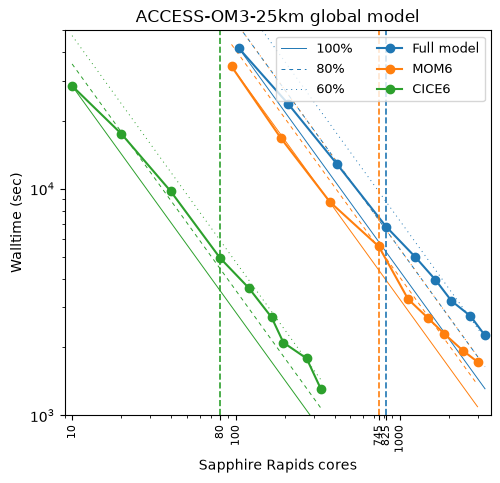

In [33]:
# for g40 NCMAS2027
import matplotlib.pyplot as plt
plt.figure()
# fig, ax = plt.subplots(figsize=(6, 7.5))
fig, ax = plt.subplots(figsize=(5.5,5))
cores = {"Full model": 745+80, 'MOM6': 745, 'CICE6': 80 } # om3-layout_MC-25km_atm_80_cpl_80_ice_10x8_ocn_745_rof_80
efficiencies = {100: '-', 80: '--', 60: ':'}
efficiencies = {100: '-', 80: (0, (4, 4)), 60: (0, (1, 4))}
# efficiencies = {100: '-', 90: '--', 80: ':', 60: '-.'}
fig2data = [l.get_xydata() for l in fig2.gca().lines]  # extract data from previous plot
for k, d in enumerate(fig2data[3:]):
    for i, (eff, linestyle) in enumerate(efficiencies.items()):
        if True: #not(k==1 and i==2): # avoid overlap
            plt.loglog(d[:,0],
                       d[0,1]*d[0,0]/(eff*d[:,0]/100),
                       color='C'+repr(k), label=f'{eff}%' if k==0 else None,
                       linestyle=linestyle, linewidth=0.7)
for d, label in zip(fig2data[0:3], cores.keys()):#["Full model", "MOM6", "CICE6"]):
    p = plt.loglog(d[:,0],d[:,1],'o-', label=label)
    plt.axvline(cores[label], color=p[-1].get_color(),
               linestyle='--', linewidth=1.2)
plt.legend(ncol=2, loc='upper right', fontsize=9)
plt.xticks(list(plt.xticks()[0]) + list(cores.values()), rotation=90, fontsize=8)
plt.xlim([9, 3600])
plt.ylim([1000, 5e4])
ax.set_xticklabels([repr(int(x)) for x in ax.get_xticks()])
plt.xlabel('Sapphire Rapids cores')
plt.ylabel('Walltime (sec)')
plt.title('ACCESS-OM3-25km global model')
plt.savefig('scaling_ACCESS-OM3-25km.png', dpi=200, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

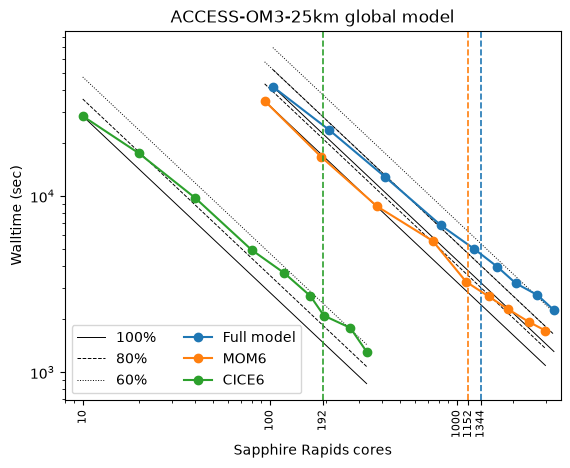

In [11]:
# for the climate NCMAS2027 proposal
import matplotlib.pyplot as plt
plt.figure()
fig, ax = plt.subplots()#figsize=(6, 7.5))
cores = {"Full model": 1152+192, 'MOM6': 1152, 'CICE6': 192 }
efficiencies = {100: '-', 80: '--', 60: ':'}
# efficiencies = {100: '-', 90: '--', 80: ':', 60: '-.'}
fig2data = [l.get_xydata() for l in fig2.gca().lines]  # extract data from previous plot
for k, d in enumerate(fig2data[3:]):
    for i, (eff, linestyle) in enumerate(efficiencies.items()):
        plt.loglog(d[:,0],
                   d[0,1]*d[0,0]/(eff*d[:,0]/100),
                   color='k', label=f'{eff}%' if k==0 else None,
                   linestyle=linestyle, linewidth=0.7)
for d, label in zip(fig2data[0:3], cores.keys()):#["Full model", "MOM6", "CICE6"]):
    p = plt.loglog(d[:,0],d[:,1],'o-', label=label)
    plt.axvline(cores[label], color=p[-1].get_color(),
               linestyle='--', linewidth=1.2)
plt.legend(ncol=2)#, fontsize=9)
plt.xticks(list(plt.xticks()[0]) + list(cores.values()), rotation=90, fontsize=8)
plt.xlim([8, 3600])
ax.set_xticklabels([repr(int(x)) for x in ax.get_xticks()])
plt.xlabel('Sapphire Rapids cores')
plt.ylabel('Walltime (sec)')
plt.title('ACCESS-OM3-25km global model')
plt.savefig('scaling_ACCESS-OM3-25km.png', dpi=200, bbox_inches='tight')

In [13]:
{e: om3_profiling.experiments[e].ncpus for e in best_experiments}

{'om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10': 104,
 'om3-layout_MC-25km_atm_20_cpl_20_ice_5x4_ocn_188_rof_20': 208,
 'om3-layout_MC-25km_atm_40_cpl_40_ice_10x4_ocn_375_rof_40': 416,
 'om3-layout_MC-25km_atm_80_cpl_80_ice_10x8_ocn_745_rof_80': 832,
 'om3-layout_MC-25km_atm_120_cpl_120_ice_12x10_ocn_1125_rof_120': 1248,
 'om3-layout_MC-25km_atm_165_cpl_165_ice_15x11_ocn_1485_rof_165': 1664,
 'om3-layout_MC-25km_atm_195_cpl_195_ice_15x13_ocn_1875_rof_195': 2080,
 'om3-layout_MC-25km_atm_270_cpl_270_ice_15x18_ocn_2430_rof_270': 2704,
 'om3-layout_MC-25km_atm_330_cpl_330_ice_22x15_ocn_2985_rof_330': 3328}

In [21]:
{e: dict(zip(e.split('_')[2::2], e.split('_')[3::2])) for e in best_experiments}

{'om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10': {'atm': '10',
  'cpl': '10',
  'ice': '5x2',
  'ocn': '94',
  'rof': '10'},
 'om3-layout_MC-25km_atm_20_cpl_20_ice_5x4_ocn_188_rof_20': {'atm': '20',
  'cpl': '20',
  'ice': '5x4',
  'ocn': '188',
  'rof': '20'},
 'om3-layout_MC-25km_atm_40_cpl_40_ice_10x4_ocn_375_rof_40': {'atm': '40',
  'cpl': '40',
  'ice': '10x4',
  'ocn': '375',
  'rof': '40'},
 'om3-layout_MC-25km_atm_80_cpl_80_ice_10x8_ocn_745_rof_80': {'atm': '80',
  'cpl': '80',
  'ice': '10x8',
  'ocn': '745',
  'rof': '80'},
 'om3-layout_MC-25km_atm_120_cpl_120_ice_12x10_ocn_1125_rof_120': {'atm': '120',
  'cpl': '120',
  'ice': '12x10',
  'ocn': '1125',
  'rof': '120'},
 'om3-layout_MC-25km_atm_165_cpl_165_ice_15x11_ocn_1485_rof_165': {'atm': '165',
  'cpl': '165',
  'ice': '15x11',
  'ocn': '1485',
  'rof': '165'},
 'om3-layout_MC-25km_atm_195_cpl_195_ice_15x13_ocn_1875_rof_195': {'atm': '195',
  'cpl': '195',
  'ice': '15x13',
  'ocn': '1875',
  'rof': '195'},
 'o

In [25]:
best_data = {e: om3_profiling.data[e] for e in best_experiments}
best_data

{'om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10': {'payu': <xarray.Dataset> Size: 888B
  Dimensions:       (region: 6)
  Coordinates:
    * region        (region) <U35 840B 'payu_setup_duration_seconds' ... 'payu_...
  Data variables:
      maximum time  (region) float64 48B [s] 7.679 4.214e+04 ... 2.355 4.215e+04,
  'MOM6': <xarray.Dataset> Size: 13kB
  Dimensions:        (region: 66)
  Coordinates:
    * region         (region) <U32 8kB 'Total runtime' ... '(Ocean forcing diag...
  Data variables:
      count          (region) int64 528B [] 1 2 1 5663 11328 ... 708 0 11327 6371
      minimum time   (region) float64 528B [s] 4.209e+04 19.03 ... 137.4 73.68
      maximum time   (region) float64 528B [s] 4.209e+04 19.23 ... 315.9 96.15
      average time   (region) float64 528B [s] 4.209e+04 19.22 ... 248.6 95.56
      time std       (region) float64 528B [s] 0.00021 0.02772 ... 42.39 2.328
      time fraction  (region) float64 528B [%] 100.0 0.0 0.0 80.8 ... 0.0 0.6 0.2
      

In [26]:
{e: v['MOM6'].region for e, v in best_data.items()}

{'om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10': <xarray.DataArray 'region' (region: 66)> Size: 8kB
 array(['Total runtime', 'Ocean Initialization', '(Ocean gen_auto_mask_table)',
        'Ocean', 'Ocean dynamics', 'Ocean thermodynamics and tracers',
        'Ocean grid generation and remapp', 'Ocean Other',
        '(Ocean tracer advection)', '(Ocean diabatic driver)',
        '(Ocean continuity equation *)', '(Ocean set BBL viscosity)',
        '(Ocean message passing *)', '(Ocean MOM_initialize_state)',
        '(Ocean init message passing *)', '(Ocean thickness diffusion *)',
        '(Ocean mixed layer restrat)', '(Ocean collective diagnostics)',
        '(Ocean Z-space diagnostics)', '(Ocean ALE)', '(Stochastic EOS)',
        '(SGS Temperature Variance)', '(Initialize from Z)',
        '(Ocean diagnostics framework)', '(Ocean diagnostics remapping)',
        '(Ocean diagnostics grid updates)', '(Ocean continuity halo updates)',
        '(Ocean init message passing)', '(

## Analysis

The above plots show the strong scaling results for the [ACCESS-OM3 25km RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_25km_jra_ryf). The underlying components are MOM6 for ocean, CICE6 for the ice model, using the NUOPC coupler from ESMF. The atmosphere and runoff are applied as forcings. Atmosphere, coupler, runoff, and CICE6 all share the same cores and run concurrently with MOM6. 

We have varied the number of Sapphire Rapids nodes between 1 and 32, and for each node count we have tried a few different ways of partitioning of the total number of available cores between the components. In the plots above, we have presented the best performing partition for each node count. For the two top plots, the x-axis is the total number of cores used in the configuration, and the y-axis is speedup relative to the one node results (left) and computational efficiency relative to the one node results (right). Also included is a table with the raw timings used to compute the parallel speedup and efficiency. The bottom plot shows the walltime as a function of the number of cores for the full model and for its two main components, MOM6 and CICE6. All the plots use the timings for the time-stepping part of the run, thus excluding initialisation and finalisation. For the per-component walltime, the timings also exclude the communications between components.

From the plots we see that, for this configuration, the parallel efficiency of the ACCESS-OM3 model quickly drops to 80% at 4 nodes and from there it slowly drops to below 60% at 32 nodes. Currently, the production runs are done using 26 nodes, with an efficiency of around 60%. The per-component data indicates that CICE6 does not scale when compared with MOM6, especially for low node counts. The poor scaling of CICE6 with respect to MOM6 is well known, and is a clear scaling bottleneck.

## Summary

- **Setup**: Strong scaling of the ACCESS-OM3 25km RYF configuration (MOM6 ocean + CICE6 sea ice, coupled via NUOPC/ESMF) on Sapphire Rapids, from 1 to 32 nodes. The best-performing core partitioning is shown at each count.
- **Scaling**: Efficiency drops quickly to 80% at 4 nodes, then declines more gradually to below 60% at 32 nodes.
- **Production**: Current production runs use 26 nodes, at roughly 60% parallel efficiency.
- **Bottleneck**: CICE6 scales poorly compared to MOM6, especially at low node counts, and is a clear limiting factor.

# Archive

Archive experiments.

In [9]:
om3_profiling.archive_experiments()

Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_270_cpl_270_ice_15x18_ocn_2430_rof_270.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_20_cpl_20_ice_4x5_ocn_188_rof_20.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_195_cpl_195_ice_15x13_ocn_1875_rof_195.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_255_cpl_255_ice_15x17_ocn_2430_rof_255.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_80_cpl_80_ice_8x10_ocn_745_rof_80.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-l